In [1]:
from PyQt5.QtWidgets import QApplication
from PyQt5.QtXml import QDomDocument
from qgis.core import QgsApplication, QgsVectorLayer, QgsProject, QgsReadWriteContext, QgsLayoutExporter, QgsLayoutItemMap, QgsPrintLayout, QgsMapSettings, QgsRectangle, QgsLayoutPoint, QgsUnitTypes, QgsLayoutSize
from qgis.gui import QgsMapCanvas

In [2]:
app = QApplication([])
qgs = QgsApplication([], False)

QStandardPaths: wrong permissions on runtime directory /run/user/1000/, 0755 instead of 0700


In [3]:
canvas = QgsMapCanvas()
project = QgsProject.instance()
layout = QgsPrintLayout(project)
layout.initializeDefaults()

In [4]:

path = '../templates/layout.qpt'
with open(path) as f:
    template_content = f.read()
    doc = QDomDocument()
    doc.setContent(template_content)

    items, ok = layout.loadFromTemplate(doc, QgsReadWriteContext(), True)
    layout.setName('My Layout')

    # Add layout to project
    project.layoutManager().addLayout(layout)

In [5]:
ilots_stables_verniquet_vasserot = QgsVectorLayer("../data/ilots/ilots_stables_verniquet_vasserot.geojson", "ilots_stables_verniquet_vasserot")
if not ilots_stables_verniquet_vasserot.isValid():
    print("Layer failed to load!")

In [6]:
project.addMapLayer(ilots_stables_verniquet_vasserot)
project.mapLayers()

{'ilots_stables_verniquet_vasserot_5d666d87_9b03_43e8_b5e7_f085cc4402d9': <QgsVectorLayer: 'ilots_stables_verniquet_vasserot' (ogr)>}

In [7]:
canvas.setExtent(ilots_stables_verniquet_vasserot.extent())
canvas.setLayers([ilots_stables_verniquet_vasserot])

In [8]:
map = QgsLayoutItemMap(layout)
map.setRect(20, 20, 20, 20)

ms = QgsMapSettings()
ms.setLayers([ilots_stables_verniquet_vasserot])
rect = QgsRectangle(ms.fullExtent())
rect.scale(1.0)
ms.setExtent(rect)
map.setExtent(rect)
layout.addLayoutItem(map)

map.attemptMove(QgsLayoutPoint(5, 20, QgsUnitTypes.LayoutMillimeters))
map.attemptResize(QgsLayoutSize(180, 180, QgsUnitTypes.LayoutMillimeters))

In [9]:
# Add map to the layout
exporter = QgsLayoutExporter(layout)
settings = QgsLayoutExporter.PdfExportSettings()

In [10]:
result = exporter.exportToPdf("../output/layout.pdf", settings)
print(result)

0


In [11]:
canvas.show()
app.exec_()

0

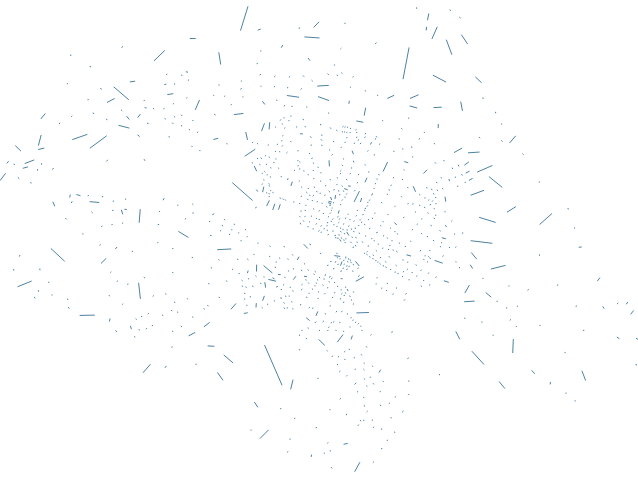

In [12]:
from IPython.display import Image

def saveImage(path, show=True):
    canvas.saveAsImage(path)
    if show:
        return Image(path)
    
saveImage("../data/map.png")